In [33]:
import sys
from pathlib import Path

parent = Path.cwd().parent
sys.path.append(str(parent))

In [34]:
from src.integrator import ComplexIntegrator
from src.integrand_builder import ContextManager, hemispherical, spherical
import oneloop_bridge
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# do this to trigger the banner here so it doesn't get in the way later
oneloop_bridge.set_renormalization_scale(1.0)

In [35]:
cm = ContextManager(force_rebuild = False) 

loaded "../evaluators/cff.so"
loaded "../evaluators/ct.so"
loaded "../evaluators/sub.so"
loaded "../evaluators/ct_int.so"


In [36]:
import symbolica


def get_integrals(masses, n_epochs, spe):
    cff_res = []
    thresh_res = []
    sub_res = []
    
    rng = symbolica.RandomNumberGenerator(0, 0)
    
    for m in tqdm(masses):
        cm.m = m

        ci3 = ComplexIntegrator(3)
        sub_int = ci3.integrate(lambda k: cm.eval(cm.sub,k), spherical,n_epochs=n_epochs, samples_per_epoch=spe, rng=rng)

        ci2 = ComplexIntegrator(2)
        ct_int = ci2.integrate(lambda k: cm.eval(cm.ct_int,k), hemispherical,n_epochs=n_epochs, samples_per_epoch=spe, rng=rng)

        ci3 = ComplexIntegrator(3)
        cff_int = ci3.integrate(lambda k: cm.eval(cm.cff,k), spherical,n_epochs=n_epochs, samples_per_epoch=spe, rng=rng)

        sub_res.append(sub_int)
        cff_res.append(cff_int)
        thresh_res.append(ct_int + sub_int)
    return cff_res, thresh_res, sub_res

def get_reference(masses):
    baseline = []
    for m in masses:
        cm.m = m
        baseline.append(cm.get_reference())
    return baseline


In [37]:
def plot_convergence(xs, cff_res, thresh_res, sub_res):
    plt.scatter(xs, [r.convergence() for r in cff_res], label = 'cff')
    plt.scatter(xs, [r.convergence() for r in thresh_res], label = 'combined')
    plt.scatter(xs, [r.convergence() for r in sub_res], label = 'subtracted', marker='.')

    plt.ylabel('convergence')
    plt.legend()

In [38]:
def plot_real_result(xs, cff_res, thresh_res, sub_res, reference_xs, reference):
    plt.plot(reference_xs, [r.real for r in reference], label = 'OneLOop')
    plt.scatter(xs, [r.real_avg for r in cff_res], label = 'cff')
    plt.scatter(xs, [r.real_avg for r in thresh_res], label = 'combined')
    plt.scatter(xs, [r.real_avg for r in sub_res], label = 'subtracted', marker='.')
    plt.legend()

def plot_imag_result(xs, cff_res, thresh_res, sub_res, reference_xs, reference):
    plt.plot(reference_xs, [r.imag for r in reference], label = 'OneLOop')
    plt.scatter(xs, [r.imag_avg for r in cff_res], label = 'cff')
    plt.scatter(xs, [r.imag_avg for r in thresh_res], label = 'combined')
    plt.scatter(xs, [r.imag_avg for r in sub_res], label = 'subtracted', marker='.')
    plt.legend()
    

In [39]:
masses = [0.5 - 1j*0.75** i for i in range(3,23)]
cff_res, thresh_res, sub_res = get_integrals(masses,n_epochs=100, spe = 100)
ref_masses = [0.5 - 1j*0.75** i for i in list(np.linspace(3,23,200))]
reference = get_reference(ref_masses)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:09<00:00,  2.08it/s]


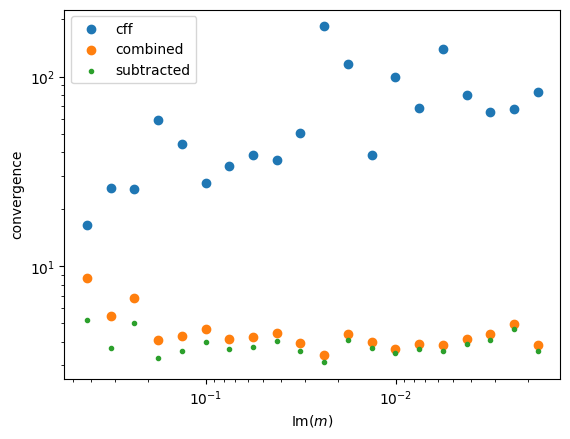

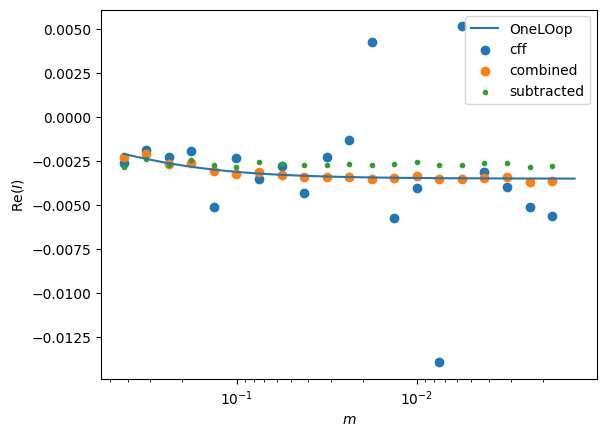

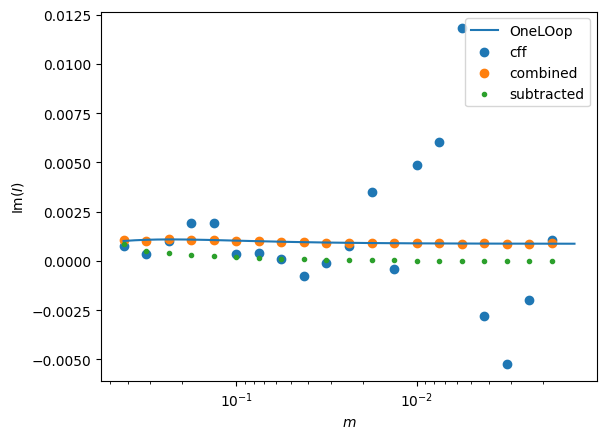

In [40]:
xs = [-m.imag for m in masses]
reference_xs = [-m.imag for m in ref_masses]
plt.show()
plot_convergence(xs, cff_res, thresh_res, sub_res)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Im($m$)')
plt.gca().invert_xaxis()
plt.show()

plot_real_result(xs, cff_res, thresh_res, sub_res, reference_xs, reference)
plt.xscale('log')
plt.xlabel('$m$')
plt.ylabel('Re($I$)')
plt.gca().invert_xaxis()
plt.show()

plot_imag_result(xs, cff_res, thresh_res, sub_res, reference_xs, reference)
plt.xscale('log')
plt.xlabel('$m$')
plt.ylabel('Im($I$)')
plt.gca().invert_xaxis()
plt.show()

In [41]:
masses = list(np.linspace(3.499**0.5,3.501**0.5,20))
cff_res, thresh_res, sub_res = get_integrals(masses,n_epochs=500, spe = 500)
ref_masses = list(np.linspace(3.499**0.5,3.501**0.5,200))
reference = get_reference(ref_masses)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [03:24<00:00, 10.22s/it]


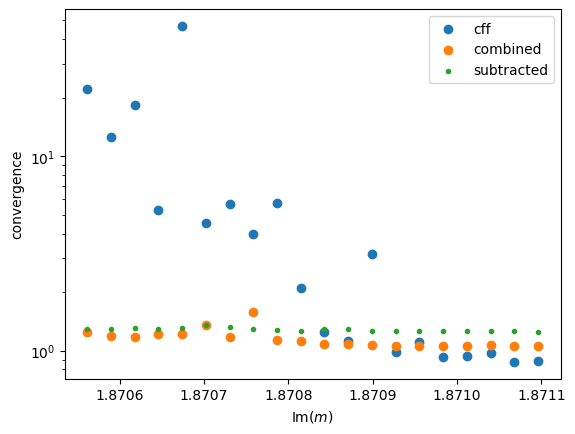

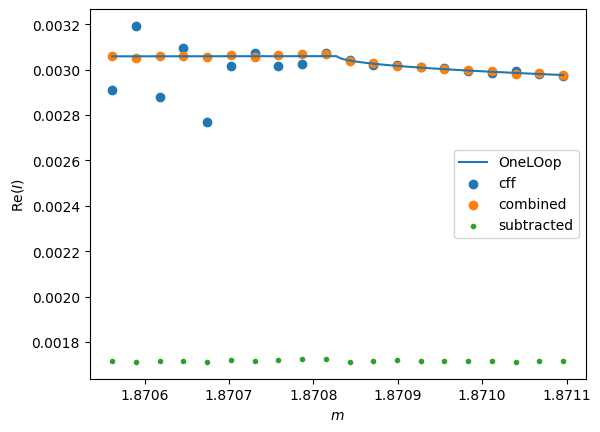

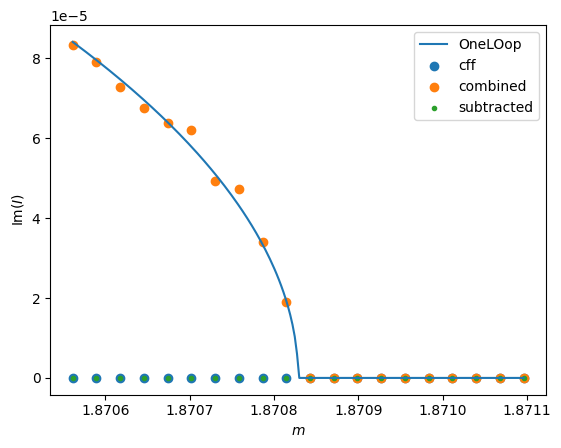

In [42]:
xs = masses
reference_xs = ref_masses
plt.show()
plot_convergence(xs, cff_res, thresh_res, sub_res)
plt.yscale('log')
plt.xlabel('Im($m$)')
plt.show()

plot_real_result(xs, cff_res, thresh_res, sub_res, reference_xs, reference)
plt.xlabel('$m$')
plt.ylabel('Re($I$)')
plt.show()

plot_imag_result(xs, cff_res, thresh_res, sub_res, reference_xs, reference)
plt.xlabel('$m$')
plt.ylabel('Im($I$)')
plt.show()

In [43]:
masses = list(np.linspace(0.4,2.1,20))
cff_res, thresh_res, sub_res = get_integrals(masses,n_epochs=100, spe = 100)
ref_masses = list(np.linspace(0.4,2.1,200))
reference = get_reference(ref_masses)

100%|██████████| 20/20 [00:09<00:00,  2.08it/s]


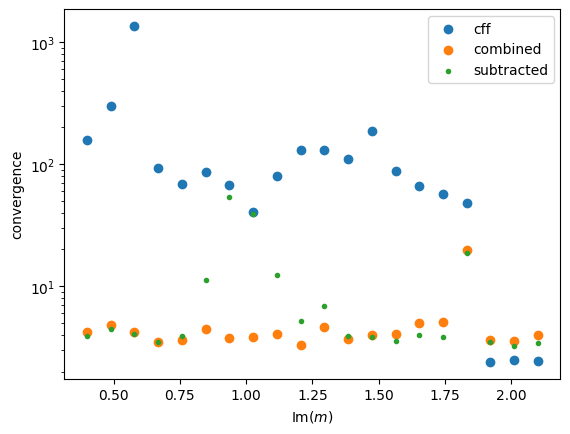

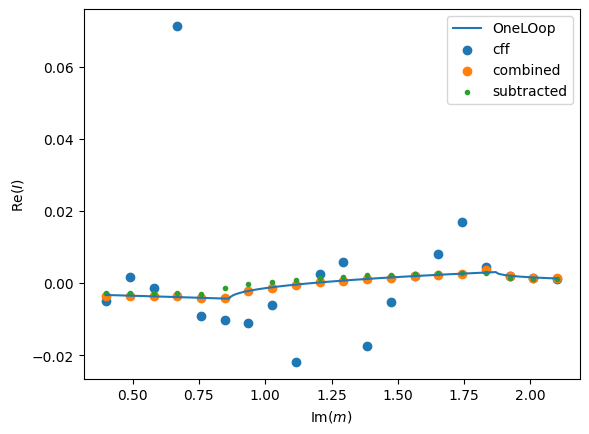

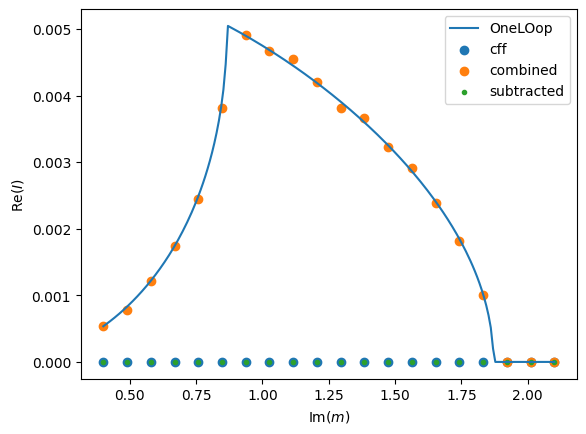

In [44]:
xs = masses
reference_xs = ref_masses
plt.show()
plot_convergence(xs, cff_res, thresh_res, sub_res)
plt.yscale('log')
plt.xlabel('Im($m$)')
plt.show()

plot_real_result(xs, cff_res, thresh_res, sub_res, reference_xs, reference)
plt.xlabel('Im($m$)')
plt.ylabel('Re($I$)')
plt.show()

plot_imag_result(xs, cff_res, thresh_res, sub_res, reference_xs, reference)
plt.xlabel('Im($m$)')
plt.ylabel('Re($I$)')
plt.show()